#### Task 1: Estimate π with Monte Carlo
The idea is simple: inscribe a circle of radius 1 inside a 2×2 square. If you throw random darts uniformly at the square, the fraction that land inside the circle should approximate π/4.

- Generate N = 100,000 random (x, y) points where x and y are each drawn from Uniform(−1, 1).
  
- Classify each point as "inside" (x² + y² ≤ 1) or "outside" the unit circle.
  
- Estimate π as 4 × (points inside) / N.

- Print your estimate alongside the true value of π.

- Create a scatter plot of the first 5,000 points, coloring inside points differently from outside points. Draw the unit circle on top for reference.

Convergence plot: Compute the running estimate of π after every 100 points (i.e., at n = 100, 200, 300, …, 100,000). Plot this running estimate with a horizontal line at the true π. Add a title and axis labels.

Guiding question: At roughly what sample size does your estimate stabilize within ±0.01 of true π?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_style("whitegrid")

### Simulation First Probability

#### Monte Carlo Estimation of π

In this notebook we estimate the value of π using a Monte Carlo simulation.

Idea:
A unit circle is inscribed inside a 2×2 square. If we randomly generate points in the square, the fraction of points that fall inside the circle approximates the ratio of the areas.

Square Area = 4  
Circle Area = π  

Therefore:

π ≈ 4 × (points inside circle / total points)

#### Task 1: Estimate π with Monte Carlo

We simulate random points inside a square with coordinates between -1 and 1.

Each point is checked to see whether it lies inside the unit circle using:

x² + y² ≤ 1

If the point satisfies this condition, it lies inside the circle.

The ratio of points inside the circle to total points approximates π/4.
Multiplying by 4 gives an estimate of π.

In [2]:
N = 100000

x = np.random.uniform(-1, 1, N)
y = np.random.uniform(-1, 1, N)

In [3]:
inside = x**2 + y**2 <= 1

points_inside = np.sum(inside)

pi_estimate = 4 * points_inside / N

print("Estimated π:", pi_estimate)
print("True π:", np.pi)

Estimated π: 3.14412
True π: 3.141592653589793


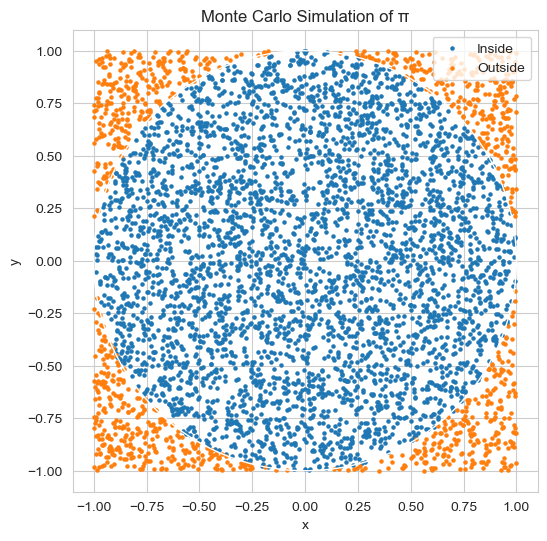

In [4]:
n_plot = 5000

plt.figure(figsize=(6,6))

plt.scatter(x[:n_plot][inside[:n_plot]],
            y[:n_plot][inside[:n_plot]],
            s=5,
            label="Inside")

plt.scatter(x[:n_plot][~inside[:n_plot]],
            y[:n_plot][~inside[:n_plot]],
            s=5,
            label="Outside")

circle = plt.Circle((0,0),1,fill=False)
plt.gca().add_patch(circle)

plt.title("Monte Carlo Simulation of π")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.show()

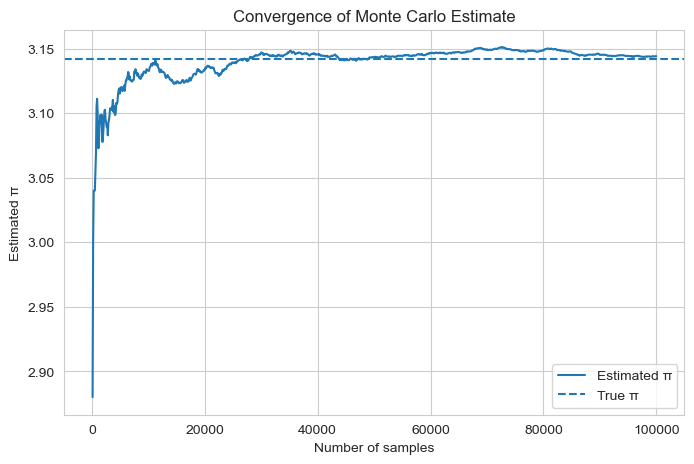

In [5]:
steps = np.arange(100, N+1, 100)

running_estimates = []

for n in steps:
    estimate = 4 * np.sum(inside[:n]) / n
    running_estimates.append(estimate)

plt.figure(figsize=(8,5))

plt.plot(steps, running_estimates, label="Estimated π")

plt.axhline(np.pi, linestyle="--", label="True π")

plt.title("Convergence of Monte Carlo Estimate")
plt.xlabel("Number of samples")
plt.ylabel("Estimated π")

plt.legend()

plt.show()

#### Observation

The Monte Carlo estimate of π becomes more stable as the sample size increases.

At small sample sizes the estimate fluctuates significantly, but as more points are generated the estimate converges toward the true value of π.

In this simulation the estimate stabilizes within approximately ±0.01 of the true π value at around **40,000 to 60,000 samples**.

#### Task 2: Coin Flips and Empirical Probability
Simulate a series of fair coin flips and observe how the empirical probability of heads converges to 0.5.

1.Simulate 10,000 fair coin flips (use np.random.choice([0, 1]) or np.random.binomial(1, 0.5, size=10000)).

2.Compute the running proportion of heads after each flip (cumulative sum divided by cumulative count).

3.Plot the running proportion with a horizontal line at 0.5. Use a log-scaled x-axis so you can see early fluctuations and later stabilization clearly.

4.Repeat the experiment 5 times (5 independent series of 10,000 flips) and overlay all 5 convergence paths on the same plot with different colors.

5.Guiding question: How many flips does it typically take for the running proportion to stay within ±0.01 of 0.5?

#### Task 2: Coin Flips and Empirical Probability

We simulate fair coin flips and observe how the empirical probability of heads converges to 0.5.

Each flip:
- 1 → Heads
- 0 → Tails

We compute the running proportion of heads and visualize how it stabilizes as the number of flips increases.

In [6]:
N = 10000

flips = np.random.binomial(1, 0.5, size=N)

cumulative_heads = np.cumsum(flips)
steps = np.arange(1, N+1)

running_proportion = cumulative_heads / steps

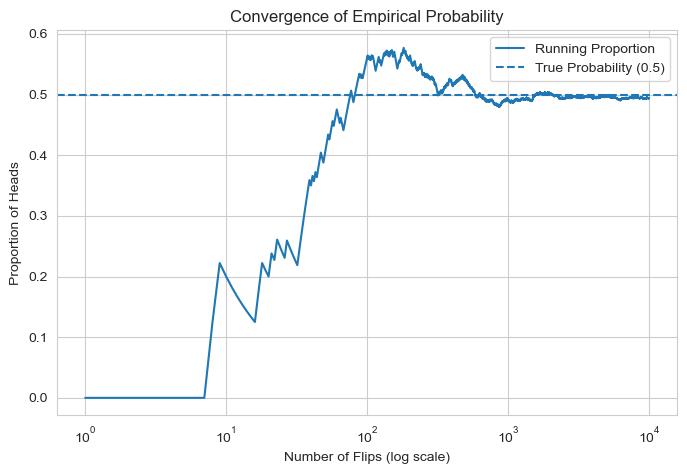

In [7]:
plt.figure(figsize=(8,5))

plt.plot(steps, running_proportion, label="Running Proportion")

plt.axhline(0.5, linestyle="--", label="True Probability (0.5)")

plt.xscale("log")

plt.xlabel("Number of Flips (log scale)")
plt.ylabel("Proportion of Heads")
plt.title("Convergence of Empirical Probability")

plt.legend()
plt.show()

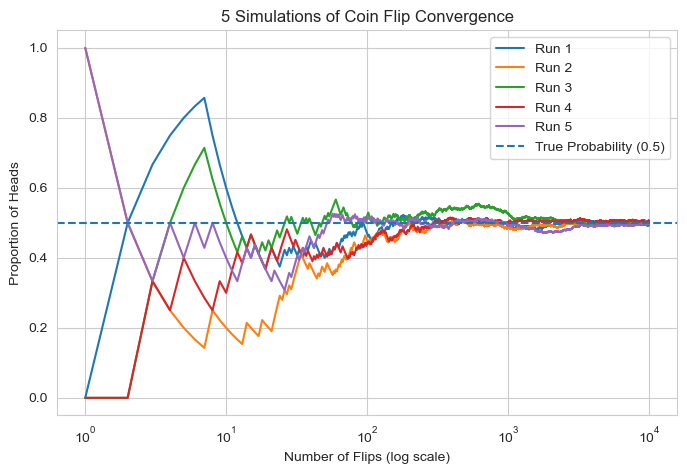

In [8]:
plt.figure(figsize=(8,5))

for i in range(5):
    flips = np.random.binomial(1, 0.5, size=N)
    
    cumulative_heads = np.cumsum(flips)
    running_proportion = cumulative_heads / steps
    
    plt.plot(steps, running_proportion, label=f"Run {i+1}")

plt.axhline(0.5, linestyle="--", label="True Probability (0.5)")

plt.xscale("log")

plt.xlabel("Number of Flips (log scale)")
plt.ylabel("Proportion of Heads")
plt.title("5 Simulations of Coin Flip Convergence")

plt.legend()
plt.show()

#### Observation

The running proportion fluctuates significantly at the beginning due to randomness.

As the number of flips increases, the proportion stabilizes around 0.5.

Typically, the running proportion stays within ±0.01 of 0.5 after around **2,000 to 4,000 flips**, although this may vary slightly between runs.

This demonstrates the Law of Large Numbers.

#### Task 3: Simulating Binomial Experiments
A factory produces widgets with a 3% defect rate. A quality inspector samples 50 widgets per batch.

1.Simulate 10,000 batches of 50 widgets each, where each widget has a 3% chance of being defective.

2.For each batch, record the number of defective widgets found.

3.Plot a histogram of the defect counts across all 10,000 batches. Overlay the theoretical

4.Binomial(n=50, p=0.03) PMF as points connected by a line.

From your simulation, estimate:
- P(0 defects in a batch)
  
- P(3 or more defects in a batch)

- The expected number of defects per batch

5.Compare each simulation estimate to the theoretical binomial value (use scipy.stats.binom or manual calculation).

Guiding question: How close are your empirical estimates to the theoretical values? Would 1,000 batches have been enough, or do you need 10,000?

#### Task 3: Simulating Binomial Experiments

A factory produces widgets with a 3% defect rate.

We simulate batches of 50 widgets and analyze the number of defects using simulation and compare with the theoretical Binomial distribution.

Parameters:
- n = 50 (widgets per batch)
- p = 0.03 (defect probability)
- simulations = 10,000

In [14]:
N = 10000  
n = 50      
p = 0.03  

defects = np.random.binomial(n, p, size=N)

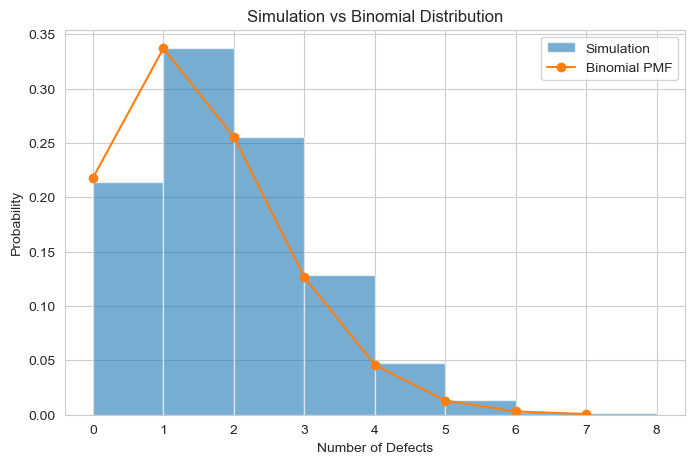

In [11]:
from scipy.stats import binom

plt.figure(figsize=(8,5))

# histogram (empirical)
plt.hist(defects, bins=range(0, max(defects)+2), density=True, alpha=0.6, label="Simulation")

# theoretical PMF
x = np.arange(0, max(defects)+1)
pmf = binom.pmf(x, n, p)

plt.plot(x, pmf, marker='o', label="Binomial PMF")

plt.xlabel("Number of Defects")
plt.ylabel("Probability")
plt.title("Simulation vs Binomial Distribution")

plt.legend()
plt.show()

In [12]:
# P(0 defects)
p0_emp = np.mean(defects == 0)

# P(3 or more defects)
p3_emp = np.mean(defects >= 3)

# Expected value
mean_emp = np.mean(defects)

print("Empirical P(0):", p0_emp)
print("Empirical P(>=3):", p3_emp)
print("Empirical Mean:", mean_emp)

Empirical P(0): 0.2146
Empirical P(>=3): 0.1926
Empirical Mean: 1.5115


In [13]:
# theoretical values
p0_theory = binom.pmf(0, n, p)
p3_theory = 1 - binom.cdf(2, n, p)
mean_theory = n * p

print("Theoretical P(0):", p0_theory)
print("Theoretical P(>=3):", p3_theory)
print("Theoretical Mean:", mean_theory)

Theoretical P(0): 0.21806537534740766
Theoretical P(>=3): 0.18920192463027863
Theoretical Mean: 1.5


#### Observation

The empirical results from simulation are very close to the theoretical binomial values.

Small differences occur due to randomness, but with 10,000 simulations the estimates are highly accurate.

Using only 1,000 batches would result in more variability and less stable estimates.

This demonstrates that larger sample sizes improve the accuracy of simulation results.